# `v71_fig1b_p38`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [2]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

# Exclude multimodal best_RFE
val_df = val_df[val_df.features != "best_RFE_10_permute"]

# n_hidden (fixed depth=0)

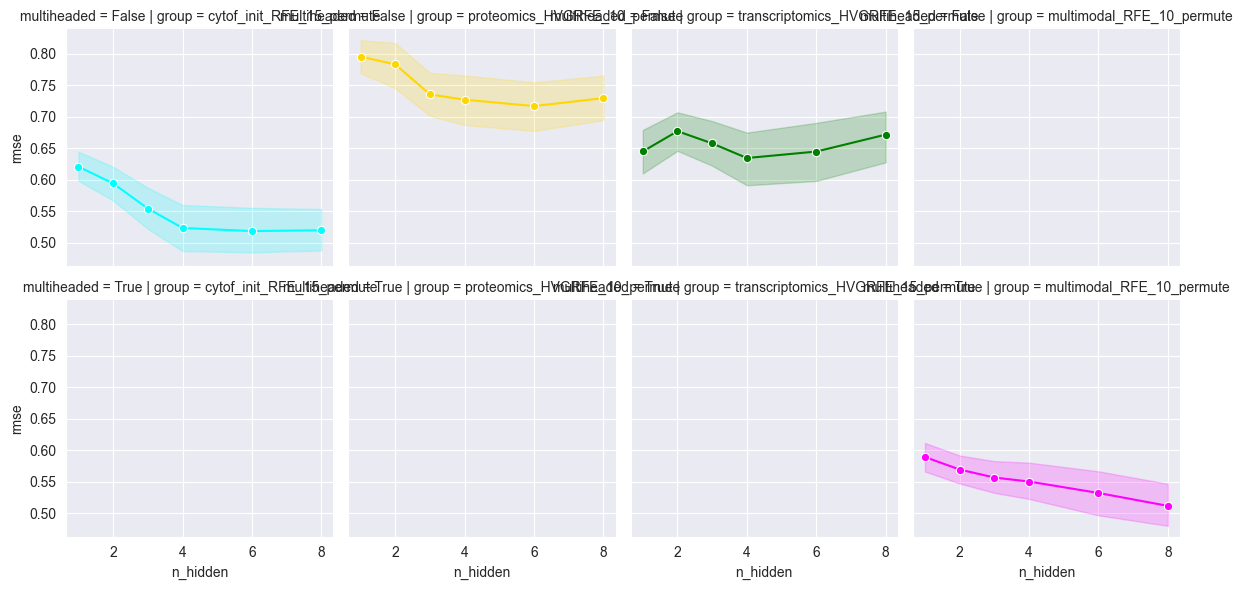

In [3]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_15_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_15_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    # "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [4]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [5]:
kruskal_wallis_groups(
   val_df[
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=17.00, p-value=0.0045, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=2.45, p-value=0.7833, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=23.60, p-value=0.0003, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=31.48, p-value=0.0000, significant? True


## Significant change with varying `n_hidden` in all contexts - definite improvement in most contexts BUT transcriptomics

# `depth` (fixed n_hidden = 2)

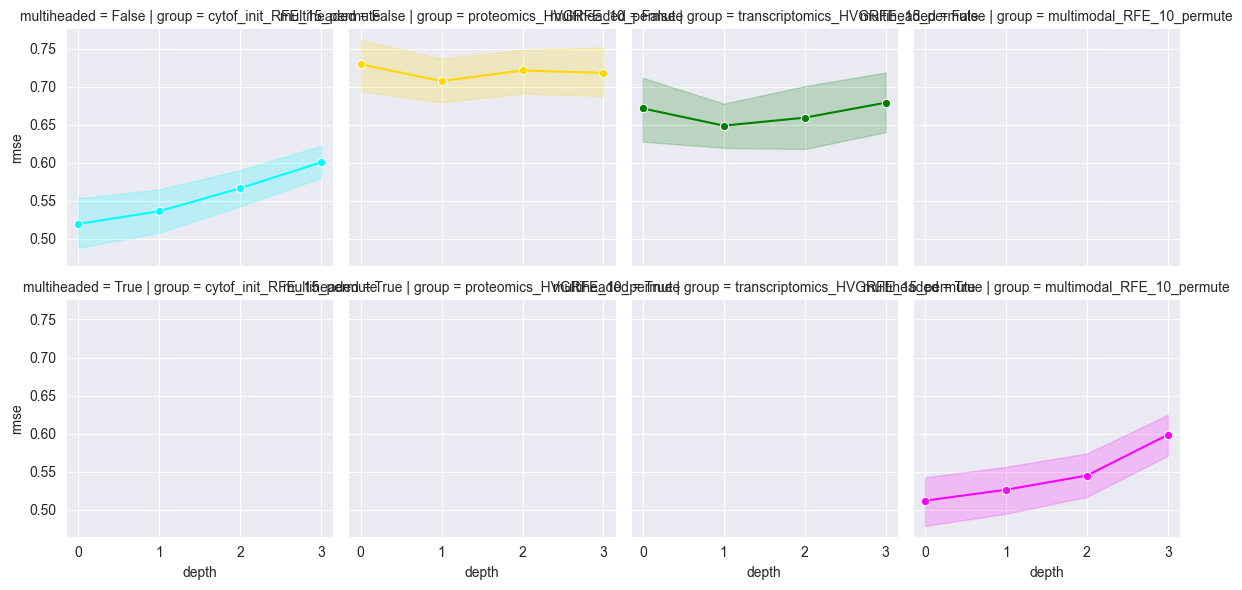

In [6]:
g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [7]:
kruskal_wallis_groups(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    "rmse",
    "depth",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.00, p-value=0.8020, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=1.48, p-value=0.6880, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=21.30, p-value=0.0001, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=16.45, p-value=0.0009, significant? True


No change in proteomics and transcriptomics; clearly hurts (significant) in cytof_init and multimodal -> depth stays at 0.

# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

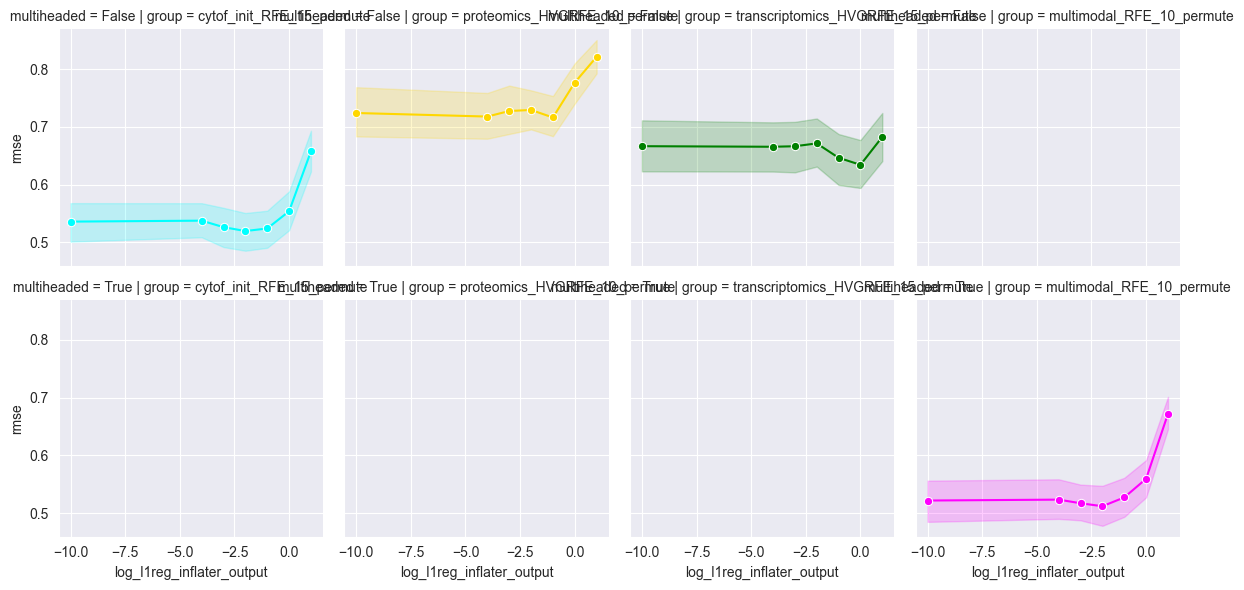

In [8]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [9]:
kruskal_wallis_groups(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=25.11, p-value=0.0003, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.06, p-value=0.6682, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=56.26, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=38.30, p-value=0.0000, significant? True


Significance is here related to worsening at high regularisation values. Nonetheless, there is a sweet spot where regularisation helps around 1e-2 (central value we choose).

# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

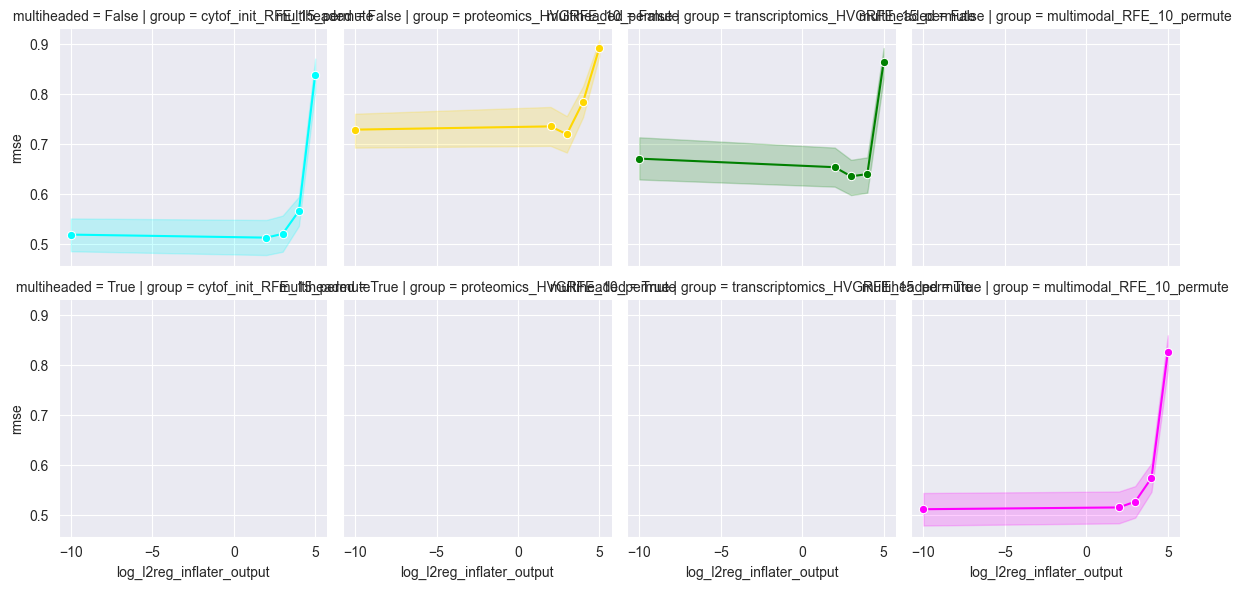

In [10]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [11]:
kruskal_wallis_groups(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=67.32, p-value=0.0000, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=74.75, p-value=0.0000, significant? True
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=103.65, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=103.14, p-value=0.0000, significant? True


No improvement for the two contexts of interest (cytof_init and multimodal) - only hurts at high value. Central value chosen is 0.

# Dropout Rate (`dropout_rate`)

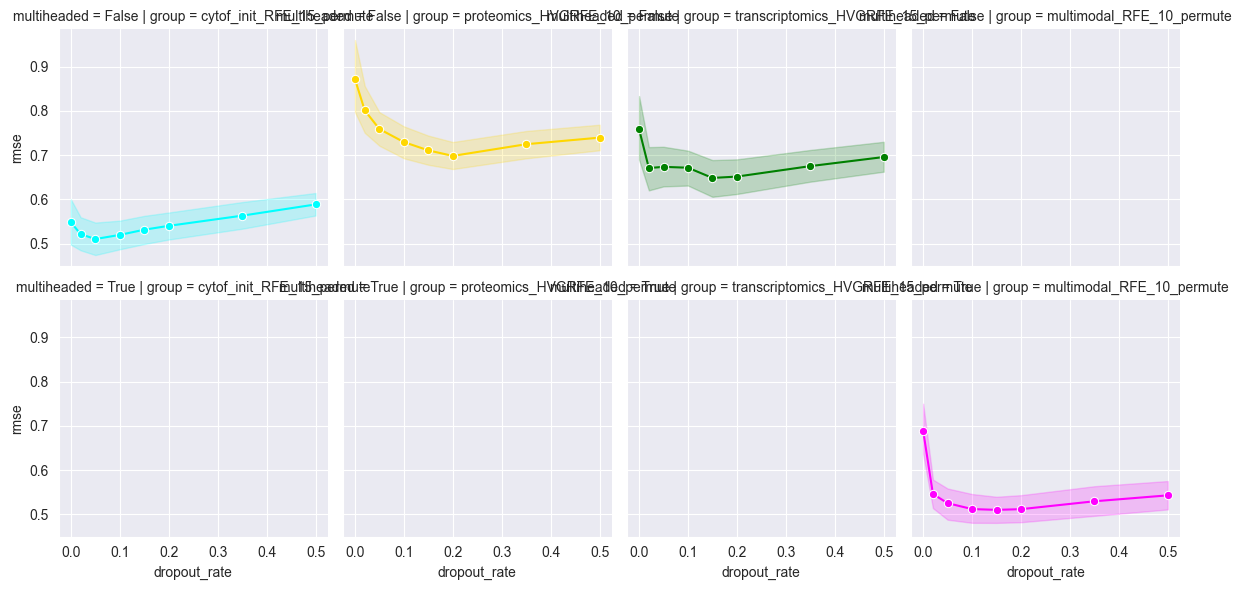

In [12]:
g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="dropout_rate",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [13]:
kruskal_wallis_groups(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4) &
        (val_df.nn_init_scale == 0.1)
    ],
    "rmse",
    "dropout_rate",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=23.20, p-value=0.0016, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=6.79, p-value=0.4511, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=37.37, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=13.81, p-value=0.0547, significant? False


Dropout helps with varying strengths - 0.1 was chosen as it helps all contexts the most.

# Reconstruction loss (`recon_loss`) -- we did not run this this time!

In [14]:
val_df.recon_loss.unique()

array([0.0001])

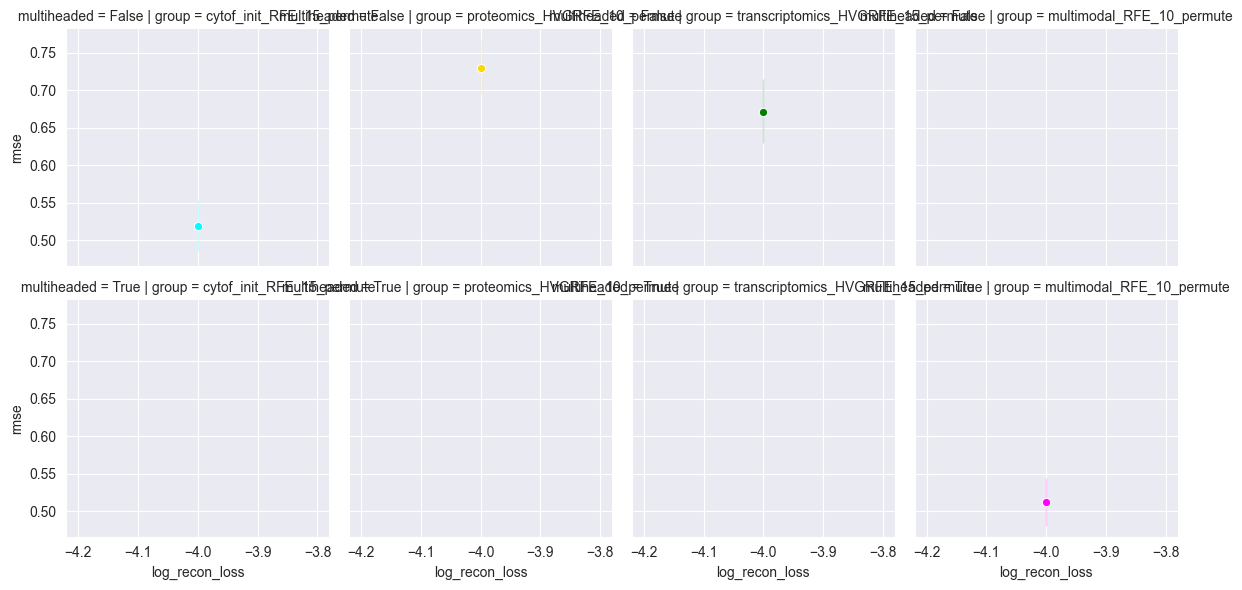

In [15]:
val_df["log_recon_loss"] = np.where(
    val_df["recon_loss"] != 0,
    np.log10(val_df["recon_loss"]),
    -10
)

g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.nn_init_scale == 0.1)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_recon_loss",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

## `nn_init_scale`

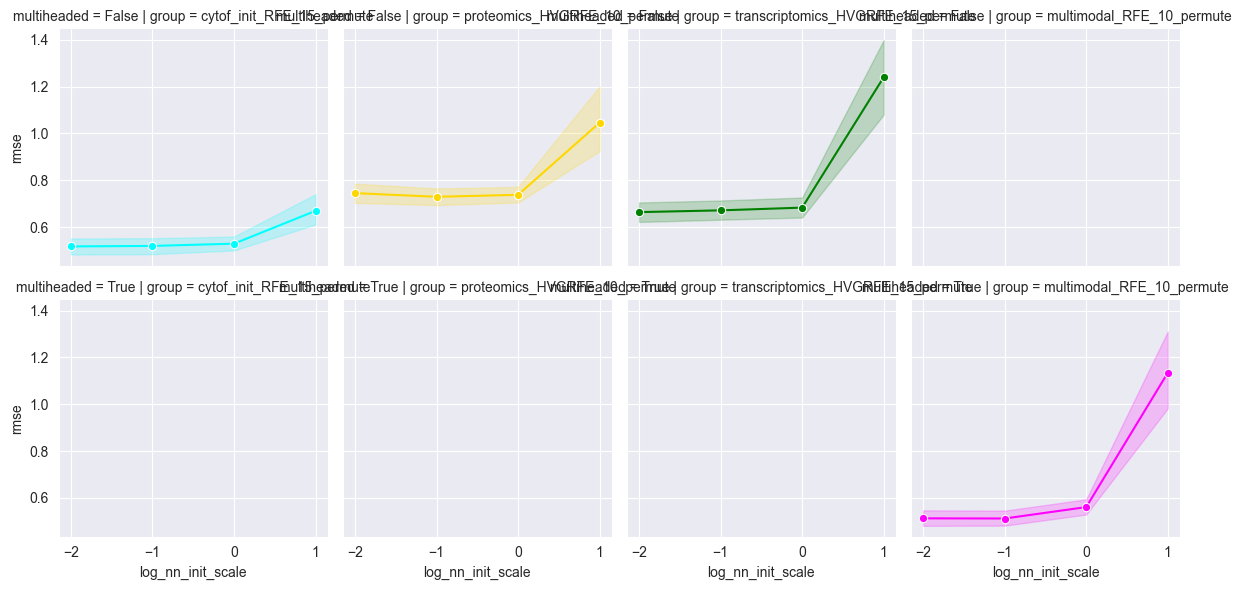

In [16]:
val_df["log_nn_init_scale"] = np.where(
    val_df["nn_init_scale"] != 0,
    np.log10(val_df["nn_init_scale"]),
    -10
)

g = sns.FacetGrid(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4)
    ],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_nn_init_scale",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [17]:
kruskal_wallis_groups(
    val_df[
        (val_df.n_hidden == 8) &
        (val_df.depth == 0) &
        (val_df.dropout_rate == 0.1) &
        (val_df.l1reg_inflater_output == 1e-2) &
        (val_df.l2reg_inflater_output == 0) &
        (val_df.recon_loss == 1e-4)
    ],
    "rmse",
    "log_nn_init_scale",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=40.65, p-value=0.0000, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=66.35, p-value=0.0000, significant? True
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=84.86, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=24.99, p-value=0.0000, significant? True


Initialisation scale has a detrimental effect when too high; 0.1 sees to be a good central value.